In [45]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt


In [54]:
import numpy as np
import pandas as pd

def norm_cdf(x): return norm.cdf(x)
def norm_ppf(x): return norm.ppf(x)


# ---------- Closed-form GBM ----------
def closed_form_pd_dd_gbm(V0, B0, sigma, mu, T=5.0):
    denom = sigma * np.sqrt(T)
    DD = (np.log(V0/B0) + (mu - 0.5*sigma**2)*T) / denom
    PD = norm_cdf(-DD)
    return PD, DD


# ---------- Monte Carlo GBM ----------
def mc_pd_dd_gbm(V0, B0, sigma, mu, T=5.0, n_paths=20000, seed=7):
    rng = np.random.default_rng(seed)
    drift = (mu - 0.5*sigma**2)*T
    volT = sigma*np.sqrt(T)

    Z = rng.standard_normal((len(V0), n_paths))
    logVT = np.log(V0)[:,None] + drift[:,None] + volT[:,None]*Z

    PD = (logVT < np.log(B0)[:,None]).mean(axis=1)
    DD = norm_ppf(1 - np.clip(PD,1e-10,1-1e-10))
    SE = np.sqrt(PD*(1-PD)/n_paths)
    return PD, DD, SE


# ---------- Monte Carlo Jump Diffusion (fixed drop) ----------
def mc_pd_dd_jump(V0, B0, sigma, mu, lam, jump_drop=0.05,
                  T=5.0, n_paths=20000, seed=7):
    rng = np.random.default_rng(seed)
    drift = (mu - 0.5*sigma**2)*T
    volT = sigma*np.sqrt(T)
    jump_log = np.log(1 - jump_drop)

    Z = rng.standard_normal((len(V0), n_paths))
    N = rng.poisson(lam[:,None]*T)

    logVT = (np.log(V0)[:,None] + drift[:,None] +
             volT[:,None]*Z + N*jump_log)

    PD = (logVT < np.log(B0)[:,None]).mean(axis=1)
    DD = norm_ppf(1 - np.clip(PD,1e-10,1-1e-10))
    SE = np.sqrt(PD*(1-PD)/n_paths)
    return PD, DD, SE


# ---------- Main Runner ----------
def run_all_models(panel_csv, out_csv,
                   mu_mode="zero",
                   scale_mult=1.5,
                   lambda_const=0.5,
                   jump_drop=0.05,
                   n_paths=50000):

    df = pd.read_csv(panel_csv, parse_dates=["date"])

    # Drift
    if mu_mode == "hist":
        df["mu_hist"] = (
            df.groupby("country_clean")["msci_ret_weekly"]
            .transform(lambda x: x.rolling(52, min_periods=10).mean().shift(1)*52)
            .fillna(0)
        )
        mu = df["mu_hist"].values
    else:
        mu = np.zeros(len(df))

    # Volatility (annualized)
    sigma = df["msci_vol_annual"].values
    B0 = df["default_barrier"].values

    # Use scaled asset value
    V0 = scale_mult * B0

    # ----- Model 1: Diffusion -----
    pd_cf, dd_cf = closed_form_pd_dd_gbm(V0, B0, sigma, mu)
    pd_mc, dd_mc, se_mc = mc_pd_dd_gbm(V0, B0, sigma, mu, n_paths=n_paths)

    # ----- Model 2: Constant Jump Intensity -----
    lam_const = np.full(len(df), lambda_const)
    pd_jc, dd_jc, se_jc = mc_pd_dd_jump(V0, B0, sigma, mu,
                                       lam_const, jump_drop,
                                       n_paths=n_paths, seed=11)

    # ----- Model 3: OVX-driven Jump Intensity -----
    lam_ovx = df["OVX"].values / 100
    pd_jo, dd_jo, se_jo = mc_pd_dd_jump(V0, B0, sigma, mu,
                                       lam_ovx, jump_drop,
                                       n_paths=n_paths, seed=22)

    # Store results
    df["pd_cf_gbm"] = pd_cf
    df["dd_cf_gbm"] = dd_cf
    df["pd_mc_gbm"] = pd_mc
    df["dd_mc_gbm"] = dd_mc

    df["pd_mc_jump_const"] = pd_jc
    df["dd_mc_jump_const"] = dd_jc

    df["pd_mc_jump_ovx"] = pd_jo
    df["dd_mc_jump_ovx"] = dd_jo

    df.to_csv(out_csv, index=False)
    return df

In [55]:
in_path = "data/processed/structural_model_panel_built.csv"
out_path =  "output/mc_gbm_results.csv"


df_res = run_all_models(
        panel_csv=in_path,
        out_csv=out_path,
        mu_mode="zero",
        scale_mult=1.5,
        lambda_const=0.5,
        jump_drop=0.05,
        n_paths=10000)


In [89]:
country = "mexico"   # change here
msci_em = [
    'brazil', 'chile', 'china', 'colombia', 'czech republic', 'czechia',
    'egypt', 'greece', 'hungary', 'india', 'indonesia', 'korea', 'south korea',
    'kuwait', 'malaysia', 'mexico', 'peru', 'philippines', 'poland', 'qatar',
    'saudi arabia', 'south africa', 'taiwan', 'thailand', 'turkey',
    'united arab emirates', 'uae'
]

df_c = df_res[df_res["country"].str.lower() == country.lower()].sort_values("date").copy()


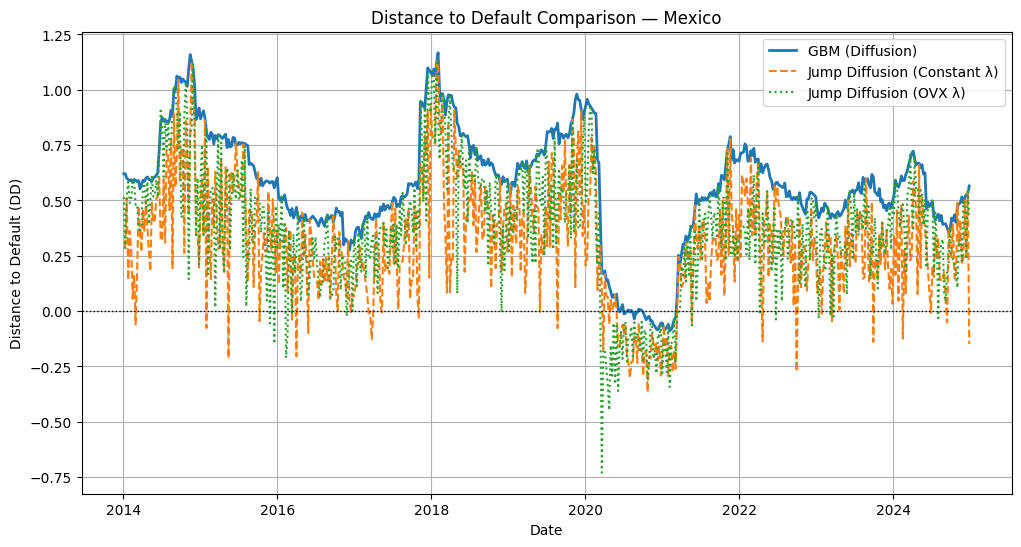

In [90]:
plt.figure(figsize=(12,6))

plt.plot(df_c["date"], df_c["dd_mc_gbm"], label="GBM (Diffusion)", linewidth=2)
plt.plot(df_c["date"], df_c["dd_mc_jump_const"], label="Jump Diffusion (Constant λ)", linestyle="--")
plt.plot(df_c["date"], df_c["dd_mc_jump_ovx"], label="Jump Diffusion (OVX λ)", linestyle=":")

plt.axhline(0, color="black", linewidth=1, linestyle=":")
plt.title(f"Distance to Default Comparison — {country.title()}")
plt.ylabel("Distance to Default (DD)")
plt.xlabel("Date")
plt.legend()
plt.grid(True)

plt.show()


In [91]:
from scipy.stats import norm

df_c["pd_gbm"]  = norm.cdf(-df_c["dd_mc_gbm"])
df_c["pd_jc"]   = norm.cdf(-df_c["dd_mc_jump_const"])
df_c["pd_jo"]   = norm.cdf(-df_c["dd_mc_jump_ovx"])


RECOVERY = 0
df_c["pd_cds"] = df_c["cds_spread"] / 10000 / (1 - RECOVERY)


import statsmodels.api as sm

def run_reg(x, y):
    X = sm.add_constant(x)
    model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
    return model.rsquared, model.params

r2_gbm, b_gbm = run_reg(df_c["pd_gbm"], df_c["pd_cds"])
r2_jc,  b_jc  = run_reg(df_c["pd_jc"],  df_c["pd_cds"])
r2_jo,  b_jo  = run_reg(df_c["pd_jo"],  df_c["pd_cds"])

print("R² Comparison")
print("GBM:        ", r2_gbm)
print("Jump Const: ", r2_jc)
print("Jump OVX:   ", r2_jo)


R² Comparison
GBM:         0.11233208139047102
Jump Const:  0.05224945670961001
Jump OVX:    0.18560579317397063
